In [27]:
# =========================================================
# 1. INSTALL DEPENDENCIES
# =========================================================
!pip install -q tensorflow scikit-learn joblib

In [28]:
# =========================================================
# 2. IMPORT LIBRARIES
# =========================================================
import os
import json
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Dense,
    Dropout,
    LSTM,
    Conv1D,
    GlobalAveragePooling1D,
    BatchNormalization
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

warnings.filterwarnings("ignore")

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


In [29]:
# =========================================================
# 3. CONFIGURATION
# =========================================================
DATA_PATH = "df_fe_24h_multistep.csv"

TIME_COL = "timestamp"
BASE_TARGET_COL = "total_consumption_mw"
HORIZONS = list(range(1, 25))
TARGET_COLS = [f"y_t+{h}" for h in HORIZONS]

SEQ_LEN = 96              # thoi gian ngày nhìn lại
TRAIN_RATIO = 0.70
VALID_RATIO = 0.15
TEST_RATIO  = 0.15

BATCH_SIZE = 64
EPOCHS = 50
RANDOM_STATE = 42

ARTIFACT_DIR = Path("cnn_lstm_24h_artifacts")
MODEL_DIR = ARTIFACT_DIR / "models"
REPORT_DIR = ARTIFACT_DIR / "reports"
PRED_DIR = ARTIFACT_DIR / "predictions"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)
PRED_DIR.mkdir(parents=True, exist_ok=True)

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

seed_everything(RANDOM_STATE)
print("Config loaded.")

Config loaded.


In [30]:
# =========================================================
# 4. LOAD DATA
# =========================================================
df = pd.read_csv(DATA_PATH)

df[TIME_COL] = pd.to_datetime(df[TIME_COL], errors="coerce")
df = df.dropna(subset=[TIME_COL]).sort_values(TIME_COL).reset_index(drop=True)

print("Shape:", df.shape)
print("Time range:", df[TIME_COL].min(), "->", df[TIME_COL].max())
display(df.head(3))

Shape: (47257, 137)
Time range: 2020-01-08 00:00:00 -> 2025-05-30 00:00:00


,Temperature,Weather,Precipitation,Chance of snow,Humidity,Wind,Wind Gust,Wind Degree,Wind Direction,Cloud Cover,...,y_t+15,y_t+16,y_t+17,y_t+18,y_t+19,y_t+20,y_t+21,y_t+22,y_t+23,y_t+24
0,25.4,patchy rain possible,0.6,0.0,89.0,7.9,15.8,295.0,wnw,89.0,...,2002.03,1735.16,1810.97,2552.90,2687.75,2944.4,3187.00,2446.80,2274.67,1663.16
1,25.1,partly cloudy,0.0,0.0,90.0,9.4,18.4,297.0,wnw,34.0,...,1735.16,1810.97,2552.90,2687.75,2944.40,3187.0,2446.80,2274.67,1663.16,1473.16
2,24.7,patchy rain possible,0.0,0.0,91.0,10.1,19.8,309.0,nw,87.0,...,1810.97,2552.90,2687.75,2944.40,3187.00,2446.8,2274.67,1663.16,1473.16,1304.00


In [31]:
# =========================================================
# 5. QUICK DATA CHECK
# =========================================================
print("Number of columns:", len(df.columns))
print("Missing values (top 20):")
display(df.isna().sum().sort_values(ascending=False).head(20))

print("Target columns found:", [c for c in TARGET_COLS if c in df.columns])

Number of columns: 137
Missing values (top 20):


,0
Temperature,0
Weather,0
Precipitation,0
Chance of snow,0
Humidity,0
Wind,0
Wind Gust,0
Wind Degree,0
Wind Direction,0
Cloud Cover,0


Target columns found: ['y_t+1', 'y_t+2', 'y_t+3', 'y_t+4', 'y_t+5', 'y_t+6', 'y_t+7', 'y_t+8', 'y_t+9', 'y_t+10', 'y_t+11', 'y_t+12', 'y_t+13', 'y_t+14', 'y_t+15', 'y_t+16', 'y_t+17', 'y_t+18', 'y_t+19', 'y_t+20', 'y_t+21', 'y_t+22', 'y_t+23', 'y_t+24']


In [32]:
# =========================================================
# 6. DEFINE INPUT FEATURES
# =========================================================
RAW_CATEGORICAL_COLS = ["Weather", "Wind Direction", "season"]

EXCLUDE_COLS = set([TIME_COL] + TARGET_COLS + RAW_CATEGORICAL_COLS)

FEATURE_COLS = [
    c for c in df.columns
    if c not in EXCLUDE_COLS and pd.api.types.is_numeric_dtype(df[c])
]

print("Number of feature columns:", len(FEATURE_COLS))
print(FEATURE_COLS)

Number of feature columns: 109
['Temperature', 'Precipitation', 'Chance of snow', 'Humidity', 'Wind', 'Wind Gust', 'Wind Degree', 'Cloud Cover', 'Visibility', 'is_weekend', 'is_holiday', 'total_consumption_mw', 'hour', 'dayofweek', 'day', 'month', 'quarter', 'dayofyear', 'weekofyear', 'is_monday', 'is_friday', 'is_saturday', 'is_sunday', 'sin_hour', 'cos_hour', 'sin_dayofweek', 'cos_dayofweek', 'sin_month', 'cos_month', 'sin_dayofyear', 'cos_dayofyear', 'Weather_freq', 'Wind Direction_freq', 'season_freq', 'total_consumption_mw_lag_1', 'total_consumption_mw_lag_2', 'total_consumption_mw_lag_3', 'total_consumption_mw_lag_6', 'total_consumption_mw_lag_12', 'total_consumption_mw_lag_24', 'total_consumption_mw_lag_25', 'total_consumption_mw_lag_26', 'total_consumption_mw_lag_48', 'total_consumption_mw_lag_72', 'total_consumption_mw_lag_168', 'total_consumption_mw_roll_mean_3', 'total_consumption_mw_roll_std_3', 'total_consumption_mw_roll_min_3', 'total_consumption_mw_roll_max_3', 'total_co

In [33]:
# =========================================================
# 7. FEATURE MANIFEST
# =========================================================
feature_manifest = {
    "target_col": BASE_TARGET_COL,
    "target_horizons": TARGET_COLS,
    "used_feature_cols": FEATURE_COLS,
    "excluded_cols": sorted(list(EXCLUDE_COLS)),
    "n_used_features": len(FEATURE_COLS)
}

with open(REPORT_DIR / "feature_manifest.json", "w", encoding="utf-8") as f:
    json.dump(feature_manifest, f, ensure_ascii=False, indent=2)

print("Model inputs are based on these variables:")
for i, col in enumerate(FEATURE_COLS, start=1):
    print(f"{i:03d}. {col}")

Model inputs are based on these variables:
001. Temperature
002. Precipitation
003. Chance of snow
004. Humidity
005. Wind
006. Wind Gust
007. Wind Degree
008. Cloud Cover
009. Visibility
010. is_weekend
011. is_holiday
012. total_consumption_mw
013. hour
014. dayofweek
015. day
016. month
017. quarter
018. dayofyear
019. weekofyear
020. is_monday
021. is_friday
022. is_saturday
023. is_sunday
024. sin_hour
025. cos_hour
026. sin_dayofweek
027. cos_dayofweek
028. sin_month
029. cos_month
030. sin_dayofyear
031. cos_dayofyear
032. Weather_freq
033. Wind Direction_freq
034. season_freq
035. total_consumption_mw_lag_1
036. total_consumption_mw_lag_2
037. total_consumption_mw_lag_3
038. total_consumption_mw_lag_6
039. total_consumption_mw_lag_12
040. total_consumption_mw_lag_24
041. total_consumption_mw_lag_25
042. total_consumption_mw_lag_26
043. total_consumption_mw_lag_48
044. total_consumption_mw_lag_72
045. total_consumption_mw_lag_168
046. total_consumption_mw_roll_mean_3
047. total_

In [34]:
# =========================================================
# 8. SAFE NUMERIC CAST
# =========================================================
for col in FEATURE_COLS + TARGET_COLS:
    df[col] = pd.to_numeric(df[col], errors="coerce")

missing_after_cast = df[FEATURE_COLS + TARGET_COLS].isna().sum().sort_values(ascending=False)
print("Missing after numeric cast (top 20):")
display(missing_after_cast.head(20))

Missing after numeric cast (top 20):


,0
Temperature,0
Precipitation,0
Chance of snow,0
Humidity,0
Wind,0
Wind Gust,0
Wind Degree,0
Cloud Cover,0
Visibility,0
is_weekend,0


In [35]:
# =========================================================
# 9. TIME-BASED SPLIT
# =========================================================
n = len(df)
train_end = int(n * TRAIN_RATIO)
valid_end = int(n * (TRAIN_RATIO + VALID_RATIO))

train_df = df.iloc[:train_end].copy()
valid_df = df.iloc[train_end:valid_end].copy()
test_df  = df.iloc[valid_end:].copy()

print("Train shape:", train_df.shape)
print("Valid shape:", valid_df.shape)
print("Test shape :", test_df.shape)

print("\nTrain time:", train_df[TIME_COL].min(), "->", train_df[TIME_COL].max())
print("Valid time:", valid_df[TIME_COL].min(), "->", valid_df[TIME_COL].max())
print("Test time :", test_df[TIME_COL].min(), "->", test_df[TIME_COL].max())

Train shape: (33079, 137)
Valid shape: (7089, 137)
Test shape : (7089, 137)

Train time: 2020-01-08 00:00:00 -> 2023-10-17 06:00:00
Valid time: 2023-10-17 07:00:00 -> 2024-08-07 15:00:00
Test time : 2024-08-07 16:00:00 -> 2025-05-30 00:00:00


In [36]:
# =========================================================
# 10. FIT SCALERS ON TRAIN ONLY
# =========================================================
x_scaler = StandardScaler()
y_scaler = StandardScaler()

x_scaler.fit(train_df[FEATURE_COLS])
y_scaler.fit(train_df[TARGET_COLS])

joblib.dump(x_scaler, REPORT_DIR / "x_scaler.pkl")
joblib.dump(y_scaler, REPORT_DIR / "y_scaler.pkl")

X_all_scaled = x_scaler.transform(df[FEATURE_COLS])
Y_all_scaled = y_scaler.transform(df[TARGET_COLS])

print("Scaled feature matrix:", X_all_scaled.shape)
print("Scaled target matrix :", Y_all_scaled.shape)

Scaled feature matrix: (47257, 109)
Scaled target matrix : (47257, 24)


In [37]:
# =========================================================
# 11. BUILD SEQUENCE DATASET
# =========================================================
def build_sequence_dataset(feature_values, target_values, timestamps, seq_len):
    X_seq, y_seq, ts_seq = [], [], []

    for i in range(seq_len - 1, len(feature_values)):
        x_window = feature_values[i - seq_len + 1:i + 1]
        y_target = target_values[i]
        ts_value = timestamps[i]

        if np.isnan(x_window).any() or np.isnan(y_target).any():
            continue

        X_seq.append(x_window)
        y_seq.append(y_target)
        ts_seq.append(ts_value)

    X_seq = np.array(X_seq, dtype=np.float32)
    y_seq = np.array(y_seq, dtype=np.float32)
    ts_seq = np.array(ts_seq)

    return X_seq, y_seq, ts_seq

all_timestamps = df[TIME_COL].values
X_seq_all, y_seq_all, ts_seq_all = build_sequence_dataset(
    X_all_scaled, Y_all_scaled, all_timestamps, SEQ_LEN
)

print("X_seq_all:", X_seq_all.shape)
print("y_seq_all:", y_seq_all.shape)
print("ts_seq_all:", ts_seq_all.shape)

X_seq_all: (47162, 96, 109)
y_seq_all: (47162, 24)
ts_seq_all: (47162,)


In [38]:
# =========================================================
# 12. SPLIT SEQUENCES BY TIME
# =========================================================
train_end_time = train_df[TIME_COL].max()
valid_end_time = valid_df[TIME_COL].max()

train_mask = ts_seq_all <= train_end_time
valid_mask = (ts_seq_all > train_end_time) & (ts_seq_all <= valid_end_time)
test_mask  = ts_seq_all > valid_end_time

X_train, y_train, ts_train = X_seq_all[train_mask], y_seq_all[train_mask], ts_seq_all[train_mask]
X_valid, y_valid, ts_valid = X_seq_all[valid_mask], y_seq_all[valid_mask], ts_seq_all[valid_mask]
X_test,  y_test,  ts_test  = X_seq_all[test_mask],  y_seq_all[test_mask],  ts_seq_all[test_mask]

print("X_train:", X_train.shape, "| y_train:", y_train.shape)
print("X_valid:", X_valid.shape, "| y_valid:", y_valid.shape)
print("X_test :", X_test.shape,  "| y_test :", y_test.shape)

X_train: (32984, 96, 109) | y_train: (32984, 24)
X_valid: (7089, 96, 109) | y_valid: (7089, 24)
X_test : (7089, 96, 109) | y_test : (7089, 24)


In [39]:
# =========================================================
# 13. ANTI-LEAKAGE CHECKS
# =========================================================
assert len(set(FEATURE_COLS).intersection(set(TARGET_COLS))) == 0, "Leakage: target columns in features"
assert X_train.shape[2] == len(FEATURE_COLS), "Feature dimension mismatch"
assert y_train.shape[1] == len(TARGET_COLS), "Target dimension mismatch"
assert ts_train.max() <= train_end_time, "Train timestamps leak beyond train range"
assert ts_valid.min() > train_end_time, "Validation starts before train ends"
assert ts_test.min() > valid_end_time, "Test starts before validation ends"

print("All anti-leakage checks passed.")

All anti-leakage checks passed.


In [40]:
# =========================================================
# 14. METRIC FUNCTIONS
# =========================================================
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def mape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return 100 * np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + 1e-8)))

def smape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return 100 * np.mean(
        2.0 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + 1e-8)
    )

print("Metric functions ready.")

Metric functions ready.


In [41]:
# =========================================================
# 15. COMMON CALLBACKS FACTORY
# =========================================================
def build_callbacks(model_name):
    return [
        EarlyStopping(
            monitor="val_loss",
            patience=10,
            min_delta=1e-4,
            restore_best_weights=True
        ),
        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=4,
            min_delta=1e-4,
            min_lr=1e-6
        ),
        ModelCheckpoint(
            filepath=str(MODEL_DIR / f"best_{model_name}.keras"),
            monitor="val_loss",
            save_best_only=True
        )
    ]

print("Callbacks factory ready.")

Callbacks factory ready.


# ***BUILD MODELS***

In [42]:
# =========================================================
# 16. BUILD CNN-LSTM HYBRID MODEL
# =========================================================
def build_cnn_lstm_model(seq_len, num_features, forecast_horizon):
    model = Sequential([
        Input(shape=(seq_len, num_features)),

        # Local temporal pattern extraction
        Conv1D(
            filters=64,
            kernel_size=3,
            padding="causal",
            activation="relu"
        ),
        BatchNormalization(),
        Dropout(0.10),

        Conv1D(
            filters=128,
            kernel_size=5,
            padding="causal",
            activation="relu"
        ),
        BatchNormalization(),
        Dropout(0.15),

        # Sequence modeling
        LSTM(96, return_sequences=False),
        Dropout(0.20),

        # Dense forecasting head
        Dense(128, activation="relu"),
        Dropout(0.20),
        Dense(64, activation="relu"),
        Dense(forecast_horizon)
    ])

    optimizer = tf.keras.optimizers.Adam(
        learning_rate=5e-4,
        clipnorm=1.0
    )

    model.compile(
        optimizer=optimizer,
        loss=tf.keras.losses.Huber(),
        metrics=["mae"]
    )
    return model

cnn_lstm_model = build_cnn_lstm_model(
    seq_len=X_train.shape[1],
    num_features=X_train.shape[2],
    forecast_horizon=y_train.shape[1]
)

cnn_lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 96, 64)         │        20,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 96, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 96, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 96, 128)        │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 96, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 96, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 96)             │        86,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 24)             │         1,560 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 171,480 (669.84 KB)

 Trainable params: 171,096 (668.34 KB)

 Non-trainable params: 384 (1.50 KB)

In [43]:
# =========================================================
# 17. TRAIN CNN-LSTM
# =========================================================
seed_everything(RANDOM_STATE)

cnn_lstm_history = cnn_lstm_model.fit(
    X_train, y_train,
    validation_data=(X_valid, y_valid),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=build_callbacks("cnn_lstm_24h"),
    verbose=1
)

Epoch 1/50
516/516 ━━━━━━━━━━━━━━━━━━━━ 19s 20ms/step - loss: 0.1655 - mae: 0.4408 - val_loss: 0.0419 - val_mae: 0.2056 - learning_rate: 5.0000e-04
Epoch 2/50
516/516 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - loss: 0.0629 - mae: 0.2646 - val_loss: 0.0378 - val_mae: 0.1949 - learning_rate: 5.0000e-04
Epoch 3/50
516/516 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - loss: 0.0555 - mae: 0.2462 - val_loss: 0.0354 - val_mae: 0.1853 - learning_rate: 5.0000e-04
Epoch 4/50
516/516 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - loss: 0.0517 - mae: 0.2362 - val_loss: 0.0354 - val_mae: 0.1864 - learning_rate: 5.0000e-04
Epoch 5/50
516/516 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - loss: 0.0493 - mae: 0.2299 - val_loss: 0.0340 - val_mae: 0.1821 - learning_rate: 5.0000e-04
Epoch 6/50
516/516 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - loss: 0.0469 - mae: 0.2235 - val_loss: 0.0331 - val_mae: 0.1774 - learning_rate: 5.0000e-04
Epoch 7/50
516/516 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - loss: 0.0457 - mae: 0.2200 - val_loss: 0.0329 - val_mae: 0.179

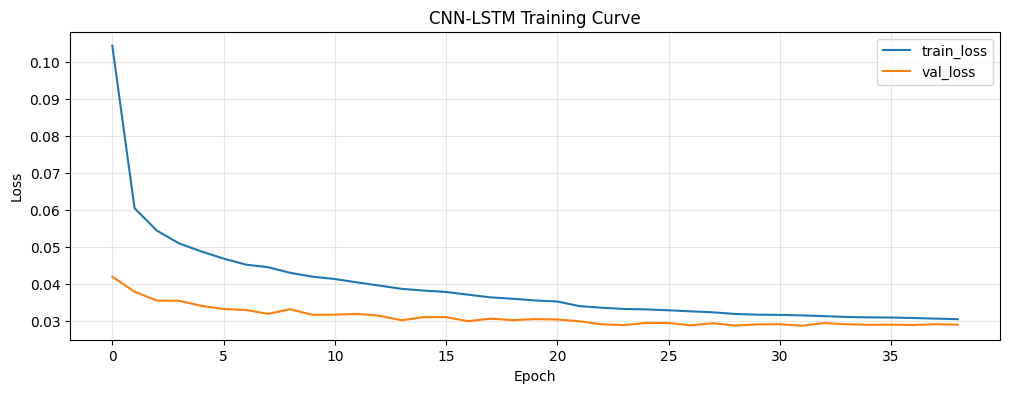

In [44]:
# =========================================================
# 18. PLOT CNN-LSTM TRAINING CURVE
# =========================================================
plt.figure(figsize=(12, 4))
plt.plot(cnn_lstm_history.history["loss"], label="train_loss")
plt.plot(cnn_lstm_history.history["val_loss"], label="val_loss")
plt.title("CNN-LSTM Training Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [45]:
# =========================================================
# 19. PREDICT ON TEST
# =========================================================
cnn_lstm_pred_test_scaled = cnn_lstm_model.predict(X_test, verbose=0)

cnn_lstm_pred_test = y_scaler.inverse_transform(cnn_lstm_pred_test_scaled)
y_test_true = y_scaler.inverse_transform(y_test)

print("cnn_lstm_pred_test:", cnn_lstm_pred_test.shape)
print("y_test_true       :", y_test_true.shape)

cnn_lstm_pred_test: (7089, 24)
y_test_true       : (7089, 24)


In [46]:
# =========================================================
# EVALUATION FUNCTION
# =========================================================
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def mape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return 100 * np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + 1e-8)))

def smape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return 100 * np.mean(
        2.0 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + 1e-8)
    )

def evaluate_multihorizon(y_true, y_pred, model_name="model"):
    rows = []
    n_horizons = y_true.shape[1]

    for i in range(n_horizons):
        yt = y_true[:, i]
        yp = y_pred[:, i]

        rows.append({
            "model": model_name,
            "horizon": i + 1,
            "label": f"y_t+{i+1}",
            "RMSE": rmse(yt, yp),
            "MAE": mean_absolute_error(yt, yp),
            "R2": r2_score(yt, yp),
            "MAPE(%)": mape(yt, yp),
            "sMAPE(%)": smape(yt, yp),
            "n_samples": len(yt)
        })

    return pd.DataFrame(rows)

print("evaluate_multihorizon is ready.")

evaluate_multihorizon is ready.


In [47]:
# =========================================================
# 20. EVALUATE CNN-LSTM
# =========================================================
cnn_lstm_metrics_df = evaluate_multihorizon(
    y_true=y_test_true,
    y_pred=cnn_lstm_pred_test,
    model_name="CNN_LSTM"
)

display(cnn_lstm_metrics_df.head())
display(cnn_lstm_metrics_df.tail())

,model,horizon,label,RMSE,MAE,R2,MAPE(%),sMAPE(%),n_samples
0,CNN_LSTM,1,y_t+1,574.603967,364.430939,0.621819,14.805488,15.954753,7089
1,CNN_LSTM,2,y_t+2,561.970028,368.273590,0.638195,15.544009,16.297250,7089
2,CNN_LSTM,3,y_t+3,534.139612,354.339691,0.673089,15.080182,15.688879,7089
3,CNN_LSTM,4,y_t+4,513.945674,346.977600,0.697265,14.969493,15.401007,7089
4,CNN_LSTM,5,y_t+5,506.348262,345.357361,0.706060,15.135023,15.400446,7089


,model,horizon,label,RMSE,MAE,R2,MAPE(%),sMAPE(%),n_samples
19,CNN_LSTM,20,y_t+20,588.663051,367.273499,0.602862,14.139612,16.024183,7089
20,CNN_LSTM,21,y_t+21,597.946878,377.529144,0.589874,14.580016,16.439257,7089
21,CNN_LSTM,22,y_t+22,598.910521,378.927216,0.588196,14.742195,16.536074,7089
22,CNN_LSTM,23,y_t+23,603.504220,384.618713,0.581522,15.158588,16.821493,7089
23,CNN_LSTM,24,y_t+24,591.272700,374.467346,0.598015,14.860934,16.282901,7089


In [48]:
# =========================================================
# SUMMARY FUNCTION
# =========================================================
import pandas as pd

def summarize_metrics(metrics_df, model_name):
    return pd.DataFrame([{
        "model": model_name,
        "avg_RMSE": metrics_df["RMSE"].mean(),
        "avg_MAE": metrics_df["MAE"].mean(),
        "avg_R2": metrics_df["R2"].mean(),
        "avg_MAPE(%)": metrics_df["MAPE(%)"].mean(),
        "avg_sMAPE(%)": metrics_df["sMAPE(%)"].mean()
    }])

print("summarize_metrics is ready.")

summarize_metrics is ready.


In [49]:
# =========================================================
# 21. CNN-LSTM SUMMARY METRICS
# =========================================================
cnn_lstm_summary_df = summarize_metrics(cnn_lstm_metrics_df, "CNN_LSTM")
display(cnn_lstm_summary_df)

,model,avg_RMSE,avg_MAE,avg_R2,avg_MAPE(%),avg_sMAPE(%)
0,CNN_LSTM,549.774284,357.428079,0.65267,14.903634,15.684185


In [52]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def mape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return 100 * np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + 1e-8)))

def smape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return 100 * np.mean(
        2.0 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + 1e-8)
    )
def evaluate_multihorizon(y_true, y_pred, model_name="model"):
    rows = []
    n_horizons = y_true.shape[1]

    for i in range(n_horizons):
        yt = y_true[:, i]
        yp = y_pred[:, i]

        rows.append({
            "model": model_name,
            "horizon": i + 1,
            "label": f"y_t+{i+1}",
            "RMSE": rmse(yt, yp),
            "MAE": mean_absolute_error(yt, yp),
            "R2": r2_score(yt, yp),
            "MAPE(%)": mape(yt, yp),
            "sMAPE(%)": smape(yt, yp),
            "n_samples": len(yt)
        })

    return pd.DataFrame(rows)

In [55]:
# =========================================================
# BUILD LONG PREDICTION DATAFRAME FUNCTION
# =========================================================
import pandas as pd

def build_prediction_long_df(ts_array, y_true, y_pred, model_name):
    rows = []
    for idx, ts in enumerate(ts_array):
        ts = pd.to_datetime(ts)
        for h in range(y_true.shape[1]):
            rows.append({
                "model": model_name,
                "ts": ts,
                "label": f"y_t+{h+1}",
                "horizon": h + 1,
                "target_time": ts + pd.Timedelta(hours=h+1),
                "actual": y_true[idx, h],
                "prediction": y_pred[idx, h]
            })
    return pd.DataFrame(rows)

print("build_prediction_long_df is ready.")

build_prediction_long_df is ready.


In [56]:
# =========================================================
# 22. BUILD LONG PREDICTION DATAFRAME
# =========================================================
cnn_lstm_pred_long_df = build_prediction_long_df(
    ts_array=ts_test,
    y_true=y_test_true,
    y_pred=cnn_lstm_pred_test,
    model_name="CNN_LSTM"
)

display(cnn_lstm_pred_long_df.head())

,model,ts,label,horizon,target_time,actual,prediction
0,CNN_LSTM,2024-08-07 16:00:00,y_t+1,1,2024-08-07 17:00:00,3862.609863,4337.215820
1,CNN_LSTM,2024-08-07 16:00:00,y_t+2,2,2024-08-07 18:00:00,3792.000000,4153.750488
2,CNN_LSTM,2024-08-07 16:00:00,y_t+3,3,2024-08-07 19:00:00,3963.310059,3936.476318
3,CNN_LSTM,2024-08-07 16:00:00,y_t+4,4,2024-08-07 20:00:00,3999.309814,3719.335205
4,CNN_LSTM,2024-08-07 16:00:00,y_t+5,5,2024-08-07 21:00:00,3134.340088,3323.196777


In [57]:
# =========================================================
# 23. EXPORT CNN-LSTM ARTIFACTS
# =========================================================
cnn_lstm_metrics_df.to_csv(REPORT_DIR / "cnn_lstm_test_metrics.csv", index=False)
cnn_lstm_summary_df.to_csv(REPORT_DIR / "cnn_lstm_summary.csv", index=False)
cnn_lstm_pred_long_df.to_csv(PRED_DIR / "cnn_lstm_predictions_long.csv", index=False)

pd.DataFrame(cnn_lstm_pred_test, columns=TARGET_COLS).to_csv(
    PRED_DIR / "cnn_lstm_pred_test_wide.csv",
    index=False
)

print("CNN-LSTM artifacts exported successfully.")

CNN-LSTM artifacts exported successfully.


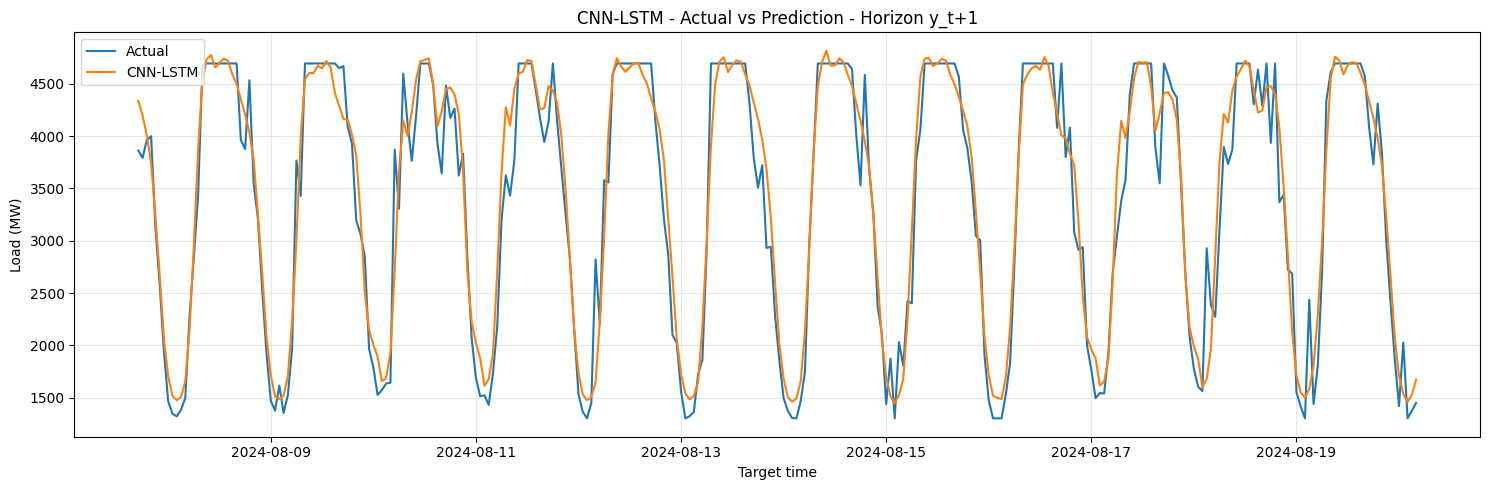

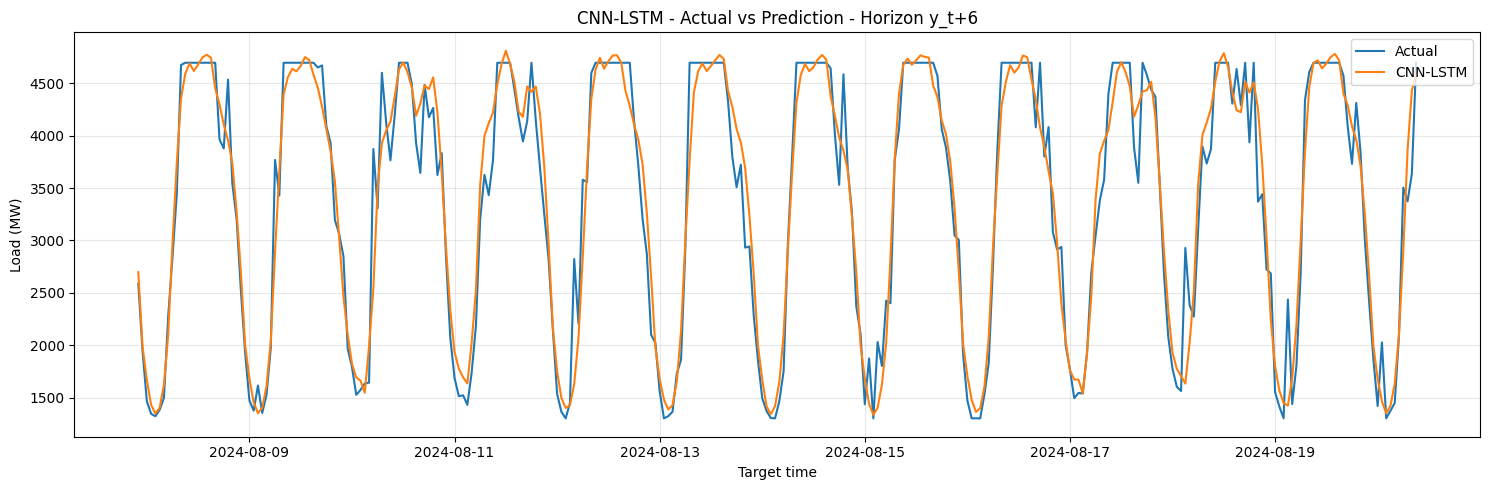

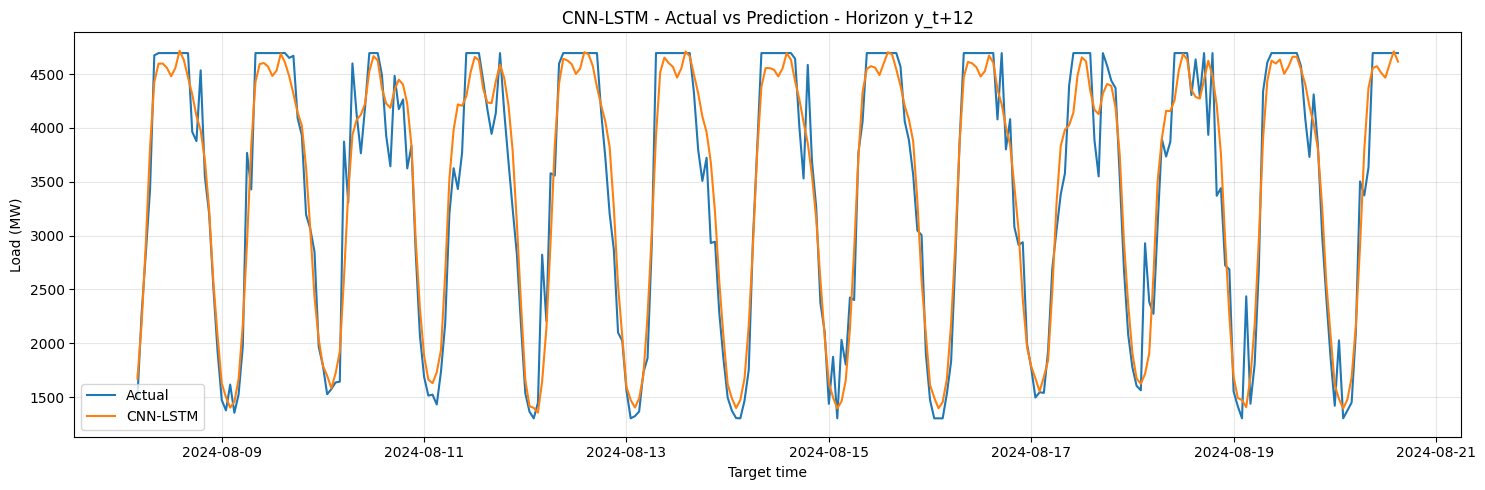

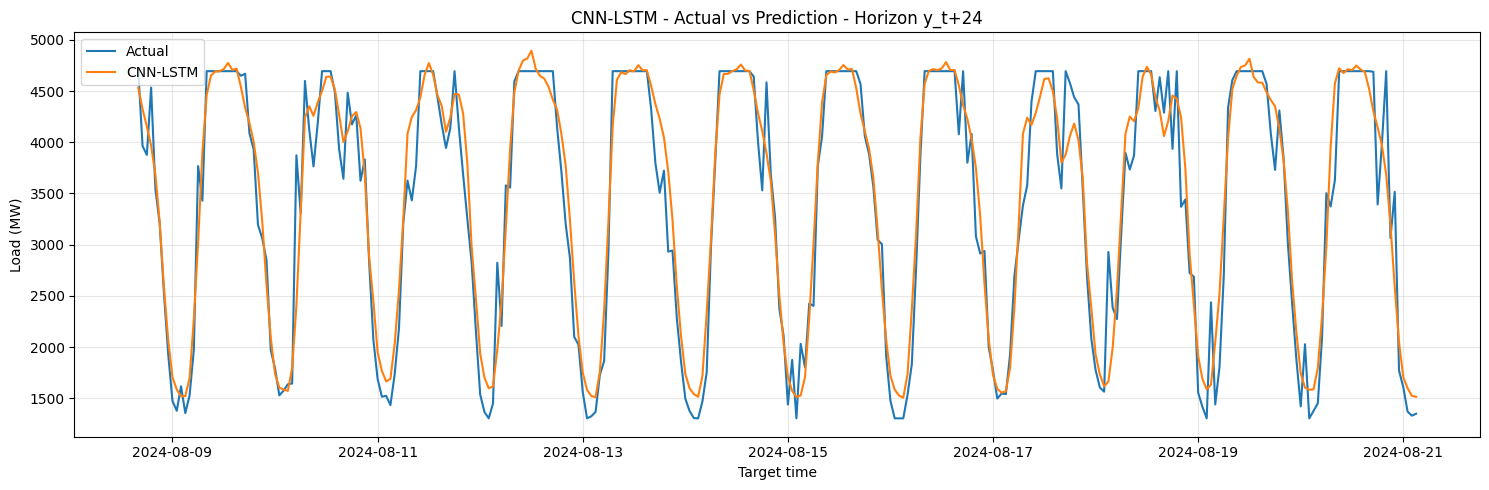

In [58]:
# =========================================================
# 24. PLOT ACTUAL VS CNN-LSTM PREDICTION
# =========================================================
demo_horizons = [1, 6, 12, 24]

for h in demo_horizons:
    tmp = cnn_lstm_pred_long_df[
        cnn_lstm_pred_long_df["horizon"] == h
    ].reset_index(drop=True)

    plt.figure(figsize=(15, 5))
    plt.plot(tmp["target_time"].iloc[:300], tmp["actual"].iloc[:300], label="Actual")
    plt.plot(tmp["target_time"].iloc[:300], tmp["prediction"].iloc[:300], label="CNN-LSTM")
    plt.title(f"CNN-LSTM - Actual vs Prediction - Horizon y_t+{h}")
    plt.xlabel("Target time")
    plt.ylabel("Load (MW)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

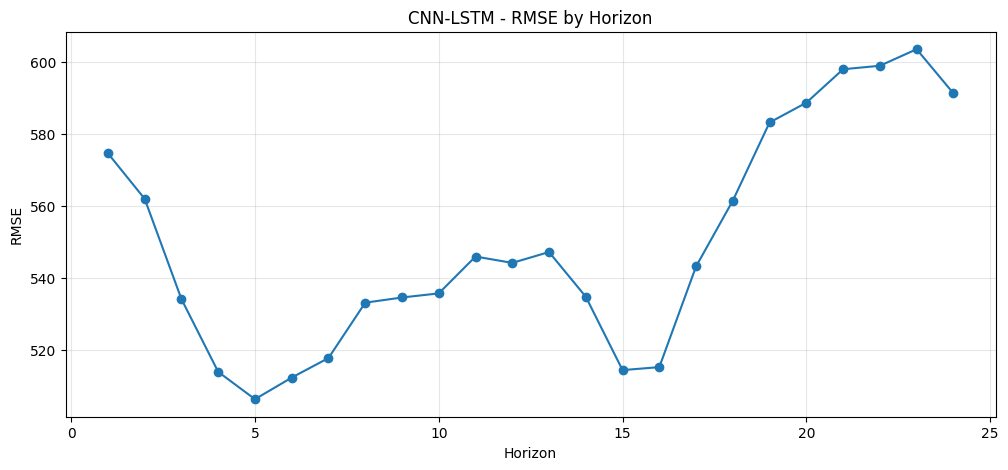

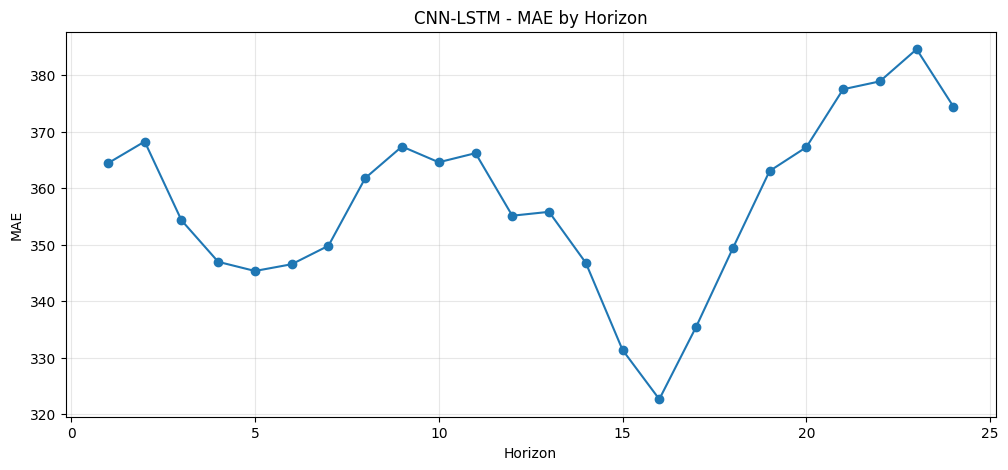

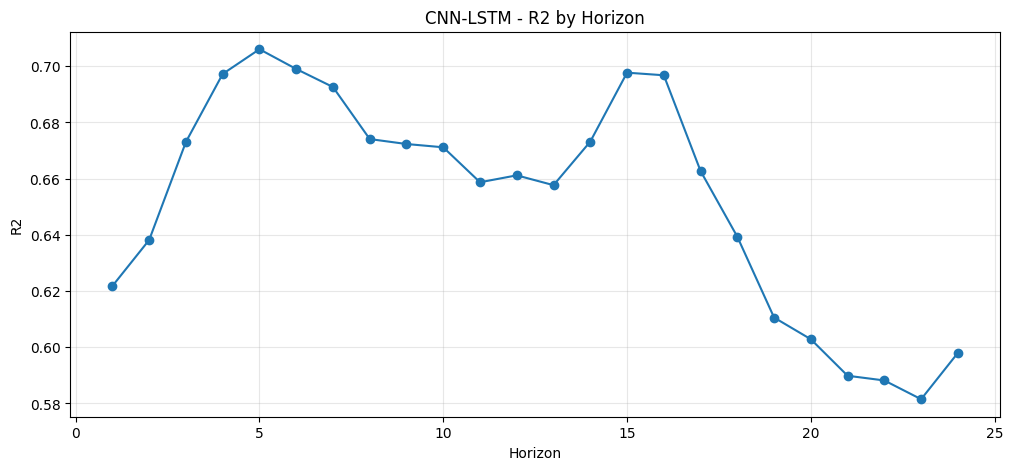

In [59]:
# =========================================================
# 25. CNN-LSTM METRIC CURVES
# =========================================================
plt.figure(figsize=(12, 5))
plt.plot(cnn_lstm_metrics_df["horizon"], cnn_lstm_metrics_df["RMSE"], marker="o")
plt.title("CNN-LSTM - RMSE by Horizon")
plt.xlabel("Horizon")
plt.ylabel("RMSE")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(cnn_lstm_metrics_df["horizon"], cnn_lstm_metrics_df["MAE"], marker="o")
plt.title("CNN-LSTM - MAE by Horizon")
plt.xlabel("Horizon")
plt.ylabel("MAE")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(cnn_lstm_metrics_df["horizon"], cnn_lstm_metrics_df["R2"], marker="o")
plt.title("CNN-LSTM - R2 by Horizon")
plt.xlabel("Horizon")
plt.ylabel("R2")
plt.grid(True, alpha=0.3)
plt.show()

In [63]:
!zip -r cnn_lstm_artifacts.zip cnn_lstm_24h_artifacts

  adding: cnn_lstm_24h_artifacts/ (stored 0%)
  adding: cnn_lstm_24h_artifacts/reports/ (stored 0%)
  adding: cnn_lstm_24h_artifacts/reports/cnn_lstm_test_metrics.csv (deflated 52%)
  adding: cnn_lstm_24h_artifacts/reports/cnn_lstm_summary.csv (deflated 25%)
  adding: cnn_lstm_24h_artifacts/reports/feature_manifest.json (deflated 82%)
  adding: cnn_lstm_24h_artifacts/reports/x_scaler.pkl (deflated 46%)
  adding: cnn_lstm_24h_artifacts/reports/y_scaler.pkl (deflated 36%)
  adding: cnn_lstm_24h_artifacts/models/ (stored 0%)
  adding: cnn_lstm_24h_artifacts/models/best_cnn_lstm_24h.keras (deflated 11%)
  adding: cnn_lstm_24h_artifacts/predictions/ (stored 0%)
  adding: cnn_lstm_24h_artifacts/predictions/cnn_lstm_predictions_long.csv (deflated 85%)
  adding: cnn_lstm_24h_artifacts/predictions/cnn_lstm_pred_test_wide.csv (deflated 56%)


After executing the cell above, you can download the `cnn_lstm_artifacts.zip` file from the Colab file browser (click the folder icon on the left panel).